### 📊 AED para explorar o IPP (Aspectos Psicopedagógicos)

**Base:** `df_base_2.parquet` — atualização gerada no Notebook `03_AED_IEG.ipynb`.

**❓Pergunta chave:**
- As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

**Sub-perguntas:**
- Qual a distribuição do IPP por ano?
- Alunos com IAN baixo (defasados) têm IPP baixo?
- Existem alunos defasados (IAN baixo) mas com IPP alto, ou vice-versa?

### ⚙️ Import e Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_parquet('../../data/db/01_silver_processed/df_base_2.parquet')

print(f'df_base: {df.shape[0]} linhas | {df.shape[1]} colunas')

df_base: 3030 linhas | 31 colunas


### Distribuição do IPP

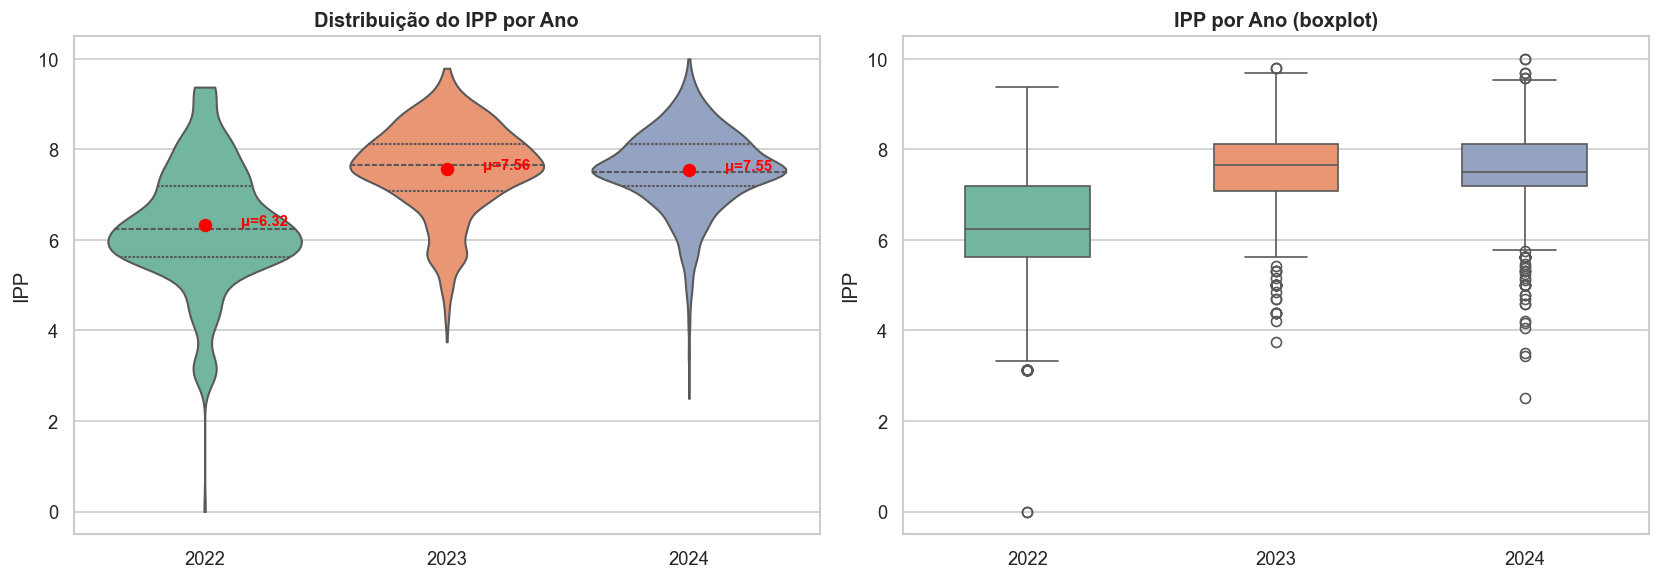

=== IPP — Estatísticas por ano ===
       count  mean   std   min   25%   50%   75%    max
ano                                                    
2022   860.0  6.32  1.34  0.00  5.62  6.25  7.19   9.38
2023   938.0  7.56  0.98  3.75  7.08  7.66  8.12   9.79
2024  1054.0  7.55  0.90  2.50  7.19  7.50  8.12  10.00


In [2]:
# Distribuição do IPP por ano
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dados_violin = df[df['IPP'].notna()].copy()
dados_violin['ano'] = dados_violin['ano'].astype(str)

sns.violinplot(data=dados_violin, x='ano', y='IPP', ax=axes[0],
               palette='Set2', inner='quartile', cut=0)

medias = dados_violin.groupby('ano')['IPP'].mean()
for i, (ano, media) in enumerate(medias.items()):
    axes[0].scatter(i, media, color='red', s=50, zorder=5)
    axes[0].text(i + 0.15, media, f'μ={media:.2f}', fontsize=9, fontweight='bold', color='red')

axes[0].set_title('Distribuição do IPP por Ano', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('IPP')

sns.boxplot(data=dados_violin, x='ano', y='IPP', ax=axes[1], palette='Set2', width=0.5)
axes[1].set_title('IPP por Ano (boxplot)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('IPP')

plt.tight_layout()
plt.show()

print('=== IPP — Estatísticas por ano ===')
print(df.groupby('ano')['IPP'].describe().round(2).to_string())

##### 💡 Insight

- IPP subiu de 2022 (mean=6.32) para 2023 (mean=7.56) e estabilizou em 2024 (mean=7.55)
- 2022 tem maior dispersão (std=1.34) e piso em 0.00 (min)
- 2023/2024 são mais compactos (std~0.9) com piso em 3.75/2.50 (min)
- Diferente do IPS e IAA (que caíram em 2023 e voltaram em 2024), o IPP **subiu em 2023 e ficou lá** 
  - a mudança parece ser permanente

❓ Essa subida de +1.24 pontos na média é porque os **mesmos alunos** foram avaliados de forma diferente, ou porque **alunos novos** entraram com IPP mais alto?

In [3]:
# Validar: o IPP subiu nos mesmos alunos ou é efeito de alunos novos?
alunos_22_23 = df[df['ano'].isin([2022, 2023])].groupby('RA').filter(lambda x: x['ano'].nunique() == 2)
pivot_ipp = alunos_22_23.pivot_table(index='RA', columns='ano', values='IPP', aggfunc='first').dropna()

pivot_ipp['delta'] = pivot_ipp[2023] - pivot_ipp[2022]

print(f'Mesmos alunos em 2022 e 2023: {len(pivot_ipp)}')
print(f'  Delta IPP médio: {pivot_ipp["delta"].mean():.2f}')
print(f'  Delta IPP mediano: {pivot_ipp["delta"].median():.2f}')
print(f'  % que subiu > 1 ponto: {(pivot_ipp["delta"] > 1).mean()*100:.1f}%')
print(f'  % que caiu > 1 ponto: {(pivot_ipp["delta"] < -1).mean()*100:.1f}%')

Mesmos alunos em 2022 e 2023: 574
  Delta IPP médio: 1.35
  Delta IPP mediano: 1.43
  % que subiu > 1 ponto: 61.5%
  % que caiu > 1 ponto: 3.5%


##### 💡 Insights

- Dos 574 alunos presentes em ambos os anos, o IPP subiu em média **+1.35 pontos**
- **61.5% subiram mais de 1 ponto** e apenas 3.5% caíram mais de 1 ponto
- Isso indica que a subida entre 2022 e 2023 é dos **mesmos alunos**
- Quando 6 em cada 10 alunos sobem mais de 1 ponto de um ano para o outro, pode ser um sinal de mudança no critério de avaliação, não de melhora real generalizada

❓ Com essa mudança de patamar em mente, o IPP ainda consegue diferenciar alunos defasados dos adequados? Ou seja: o IPP **confirma ou contradiz** a defasagem identificada pelo IAN?

### IPP vs IAN

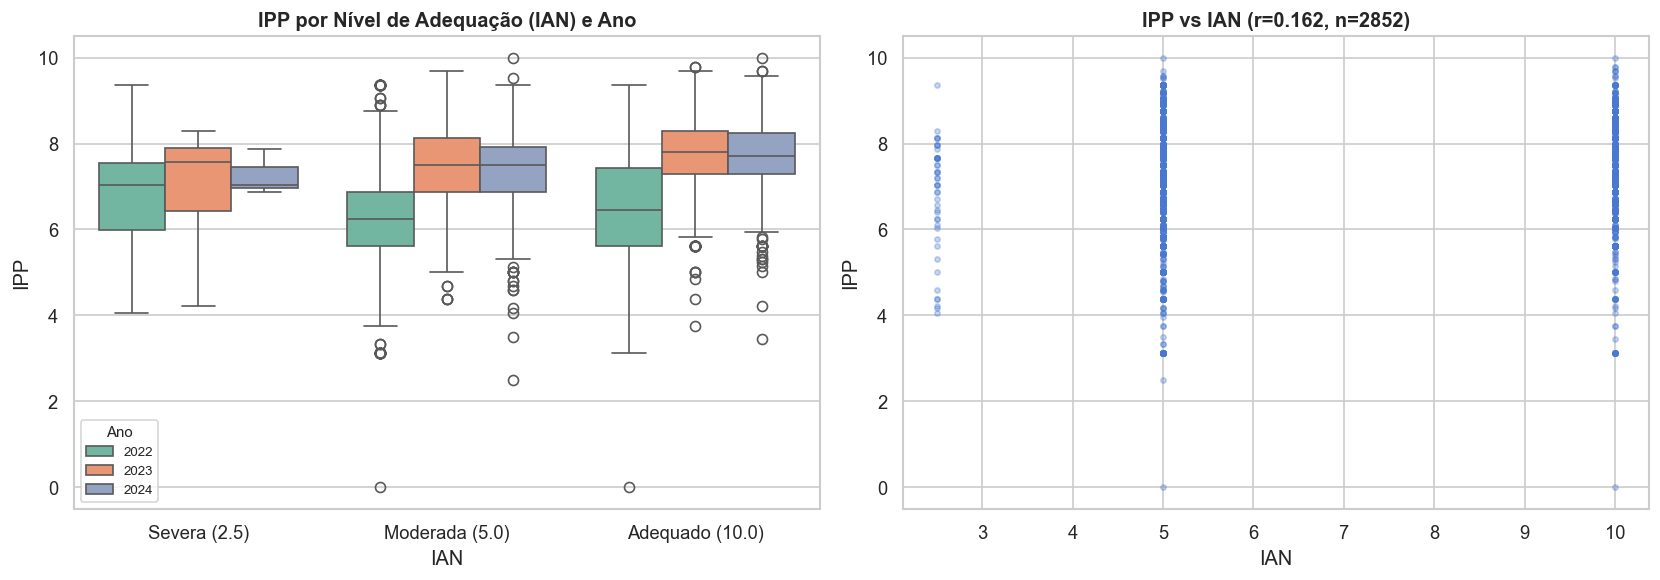

=== IPP médio por IAN e ano ===
                 mean             count          
ano              2022  2023  2024  2022 2023 2024
grupo_ian                                        
Adequado (10.0)  6.50  7.67  7.69   259  388  520
Moderada (5.0)   6.23  7.50  7.41   573  536  531
Severa (2.5)     6.61  6.96  7.26    28   14    3


In [4]:
# IPP médio por grupo de IAN — o IPP confirma ou contradiz a defasagem?
df_ipp_ian = df[df['IPP'].notna() & df['IAN'].notna()].copy()
df_ipp_ian['grupo_ian'] = df_ipp_ian['IAN'].map({
    2.5: 'Severa (2.5)', 5.0: 'Moderada (5.0)', 10.0: 'Adequado (10.0)'
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot IPP por IAN
ordem = ['Severa (2.5)', 'Moderada (5.0)', 'Adequado (10.0)']
sns.boxplot(data=df_ipp_ian, x='grupo_ian', y='IPP', hue='ano',
            order=ordem, ax=axes[0], palette='Set2')
axes[0].set_title('IPP por Nível de Adequação (IAN) e Ano', fontweight='bold')
axes[0].set_xlabel('IAN')
axes[0].set_ylabel('IPP')
axes[0].legend(title='Ano', loc='lower left', fontsize=8, title_fontsize=9)

# Correlação IPP × IAN
corr = df_ipp_ian['IPP'].corr(df_ipp_ian['IAN'])
axes[1].scatter(df_ipp_ian['IAN'], df_ipp_ian['IPP'], alpha=0.3, s=10)
axes[1].set_title(f'IPP vs IAN (r={corr:.3f}, n={len(df_ipp_ian)})', fontweight='bold')
axes[1].set_xlabel('IAN')
axes[1].set_ylabel('IPP')

plt.tight_layout()
plt.show()

# Tabela resumo
resumo = df_ipp_ian.pivot_table(
    index='grupo_ian', columns='ano', values='IPP', aggfunc=['mean', 'count']
).round(2)
print('=== IPP médio por IAN e ano ===')
print(resumo.to_string())

##### 💡 Insights

- Segundo o scatter plot, IPP vs IAN mostra uma correlação muito fraca (r=0.162)
  - Logo, o IPP **não reflete a defasagem** identificada pelo IAN
- Em 2022, as 3 faixas de IAN têm IPP praticamente igual (~6.2–6.6)
  - Logo, me parece que a avaliação psicopedagógica (IPP) não diferenciava defasados de adequados (IAN)
- Em 2023/2024, diferença levemente maior mas ainda pequena:
  - Adequado (7.67) vs Moderada (7.50) — apenas 0.17 pontos
- Dado contra-intuitivo, ou no mínimo, curioso:
  - Em 2022, alunos com defasagem severa (IAN=2.5) tinham IPP **mais alto** (6.61) que moderados (6.23)
  - Talvez a equipe psicopedagófica desse mais atenção aos alunos com mais dificuldade?
- Amostra muito pequena de defasagem "Severa" em 2023 (n=14) e 2024 (n=3) acabam por não ajudar a tirar conclusões

❓ Quantos alunos estão em situação de **contradição** — defasados mas com IPP alto, ou adequados mas com IPP baixo?

=== Concordância IPP vs IAN (mediana IPP=7.50) ===
  Confirma: defasado + IPP baixo          :   917 (32.2%)
  Contradiz: defasado + IPP alto          :   768 (26.9%)
  Confirma: adequado + IPP alto           :   714 (25.0%)
  Contradiz: adequado + IPP baixo         :   453 (15.9%)

  Total confirma:  57.2%
  Total contradiz: 42.8%


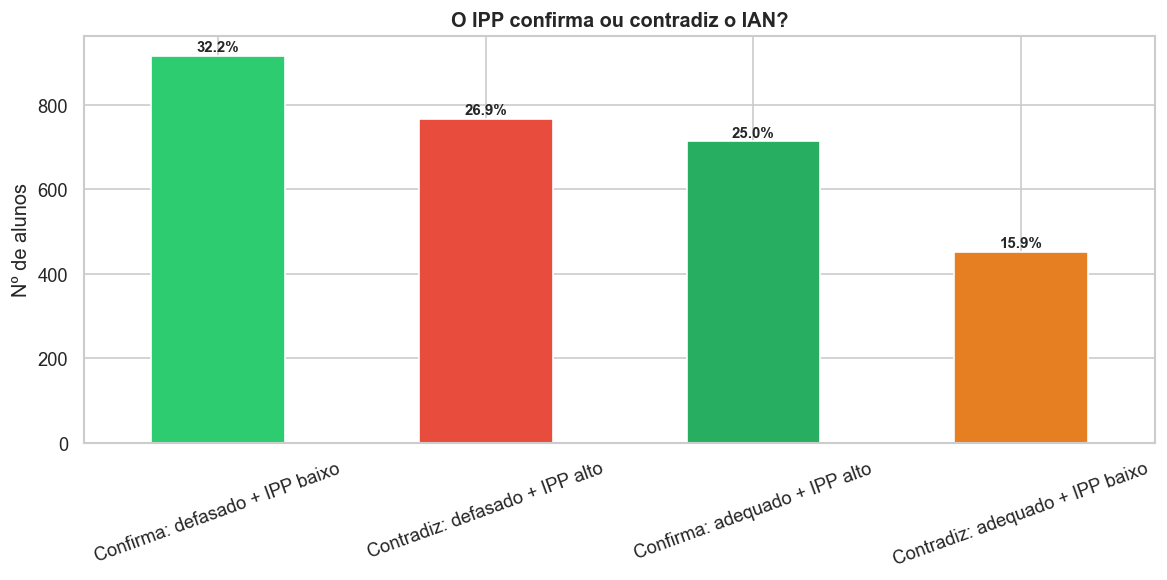

In [5]:
# Classificar concordância: IPP concorda ou discorda do IAN?
df_cd = df[df['IPP'].notna() & df['IAN'].notna()].copy()

# Definir: IPP alto (>=7) vs baixo (<7) cruzado com IAN
# Usar a mediana como referência para IPP alto/baixo
mediana_ipp = df_cd['IPP'].median() 

def classificar_concordancia(row):
    defasado = row['IAN'] < 10
    ipp_baixo = row['IPP'] < mediana_ipp
    
    if defasado and ipp_baixo:
        return 'Confirma: defasado + IPP baixo'
    if defasado and not ipp_baixo:
        return 'Contradiz: defasado + IPP alto'
    if not defasado and not ipp_baixo:
        return 'Confirma: adequado + IPP alto'
    return 'Contradiz: adequado + IPP baixo'

df_cd['concordancia'] = df_cd.apply(classificar_concordancia, axis=1)

# Resumo geral
ct = df_cd['concordancia'].value_counts()
ct_pct = (ct / len(df_cd) * 100).round(1)

print(f'=== Concordância IPP vs IAN (mediana IPP={mediana_ipp:.2f}) ===')
for cat in ct.index:
    print(f'  {cat:40}: {ct[cat]:5d} ({ct_pct[cat]}%)')

confirma = ct_pct.filter(like='Confirma').sum()
contradiz = ct_pct.filter(like='Contradiz').sum()
print(f'\n  Total confirma:  {confirma:.1f}%')
print(f'  Total contradiz: {contradiz:.1f}%')

# Visualização
fig, ax = plt.subplots(figsize=(10, 5))

cores_conc = {
    'Confirma: defasado + IPP baixo': '#2ecc71',
    'Confirma: adequado + IPP alto': '#27ae60',
    'Contradiz: defasado + IPP alto': '#e74c3c',
    'Contradiz: adequado + IPP baixo': '#e67e22'
}

ct.plot(kind='bar', ax=ax, color=[cores_conc[c] for c in ct.index])
ax.set_title('O IPP confirma ou contradiz o IAN?', fontweight='bold')
ax.set_ylabel('Nº de alunos')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)

for i, (cat, n) in enumerate(ct.items()):
    ax.text(i, n + 10, f'{ct_pct[cat]}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

##### 💡 Insights

- Segundo os dados acima, aparentemente o IPP não é um espelho do IAN: 57.2% x 42.8%
  - Acredito que precsaríamos ver um % maior de confirmação para ter uma relação/associação forte
  - A taxa de 42.8% de contradição confirma que o IPP mede uma dimensão diferente do IAN
- O maior grupo de contradição são **defasados com IPP alto** (26.9%)
  - Me leva a entender que são alunos atrasados na fase mas que a equipe psicopedagógica avalia positivamente
  - Possível sinal de potencial ou progresso não capturado pela defasagem numérica
- **15.9% são adequados com IPP baixo**
  - Esse dado mostra alunos sem defasagem, porém com fragilidades psicopedagógicas detectadas
  - Grupo potencialmente em risco de defasagem futura

❓ Esse padrão de concordância/contradição mudou ao longo dos anos, considerando a recalibração do IPP em 2023?

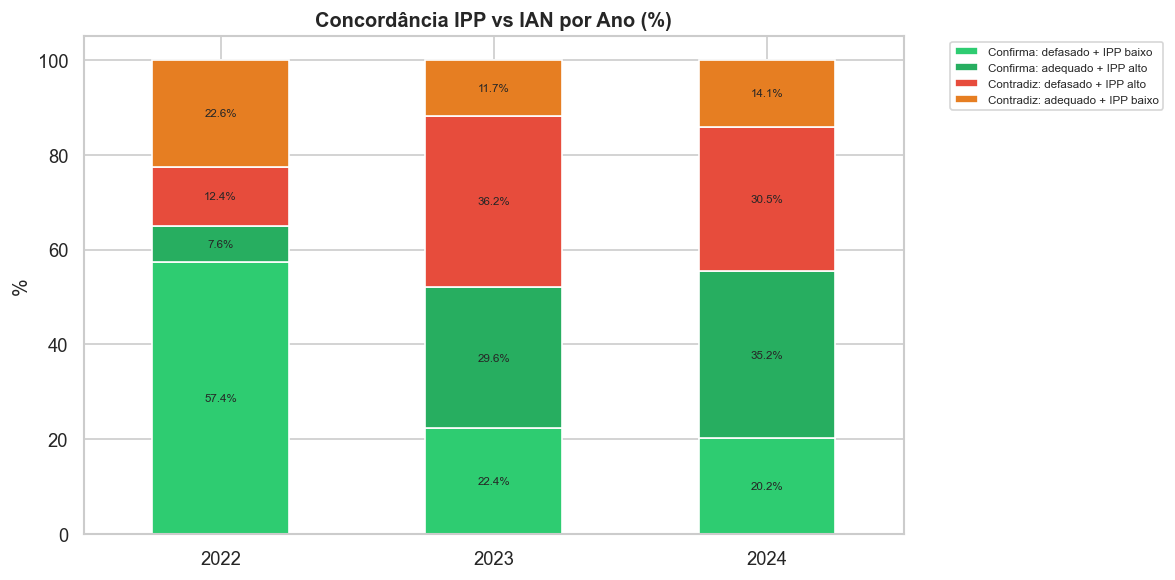

=== Concordância por ano (%) ===
concordancia  Confirma: defasado + IPP baixo  Confirma: adequado + IPP alto  Contradiz: defasado + IPP alto  Contradiz: adequado + IPP baixo
ano                                                                                                                                         
2022                                    57.4                            7.6                            12.4                             22.6
2023                                    22.4                           29.6                            36.2                             11.7
2024                                    20.2                           35.2                            30.5                             14.1


In [6]:
# Concordância por ano — mudou ao longo do tempo?
ct_ano = pd.crosstab(df_cd['ano'], df_cd['concordancia'], normalize='index') * 100

ordem_conc = ['Confirma: defasado + IPP baixo', 'Confirma: adequado + IPP alto',
              'Contradiz: defasado + IPP alto', 'Contradiz: adequado + IPP baixo']
ct_ano = ct_ano[ordem_conc]

fig, ax = plt.subplots(figsize=(10, 5))
ct_ano.plot(kind='bar', stacked=True, ax=ax,
            color=['#2ecc71', '#27ae60', '#e74c3c', '#e67e22'])
ax.set_title('Concordância IPP vs IAN por Ano (%)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('%')
ax.legend(title='', fontsize=7, bbox_to_anchor=(1.05, 1))
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=7)

plt.tight_layout()
plt.show()

print('=== Concordância por ano (%) ===')
print(ct_ano.round(1).to_string())

##### 💡 Insights

- A taxa de confirmação caiu ao longo dos anos: 65.0% (2022) → 52.0% (2023) → 55.4% (2024)
- A principal mudança: "defasados + IPP alto" saltou de 12.4% (2022) para 36.2% (2023)

**Duas hipóteses para o aumento de "defasados + IPP alto":**
1. **Metodologia diferente:** uma possível mudança na metodologia em 2023 inflou as notas, enquanto o IAN (automático) não mudou 
2. **Progresso real:** alunos defasados estão evoluindo psicopedagogicamente (engajamento, comportamento, confiança) mas ainda não zeraram a defasagem — o IAN é rígido enquanto o IPP captura nuances de evolução

❓Será que consigo saber se os mesmos alunos defasados + IPP baixo em 2022 melhoraram o IPP ao longo dos anos?

In [7]:
# Alunos que avançaram de fase entre anos mas continuam defasados (IAN < 10)
# Comparar o IPP desses alunos com os que NÃO avançaram

df_evol = df[df['IPP'].notna() & df['IAN'].notna()].copy()
df_evol['nivel_num'] = pd.to_numeric(df_evol['nivel'], errors='coerce')

# Pegar nível e IPP de cada ano por aluno
pares = []
for ra, grupo in df_evol.groupby('RA'):
    grupo = grupo.sort_values('ano')
    for i in range(len(grupo) - 1):
        atual = grupo.iloc[i]
        proximo = grupo.iloc[i + 1]
        
        # Só alunos defasados nos dois anos (IAN < 10)
        if atual['IAN'] < 10 and proximo['IAN'] < 10:
            pares.append({
                'RA': ra,
                'ano_atual': atual['ano'],
                'nivel_atual': atual['nivel_num'],
                'nivel_proximo': proximo['nivel_num'],
                'IPP_atual': atual['IPP'],
                'IPP_proximo': proximo['IPP'],
                'IAN_atual': atual['IAN'],
                'IAN_proximo': proximo['IAN'],
            })

df_pares_ipp = pd.DataFrame(pares).dropna(subset=['nivel_atual', 'nivel_proximo'])
df_pares_ipp['avancou_fase'] = df_pares_ipp['nivel_proximo'] > df_pares_ipp['nivel_atual']
df_pares_ipp['delta_IPP'] = df_pares_ipp['IPP_proximo'] - df_pares_ipp['IPP_atual']

print(f'Alunos defasados em anos consecutivos: {len(df_pares_ipp)}')
print(f'  Avançaram de fase: {df_pares_ipp["avancou_fase"].sum()}')
print(f'  Não avançaram: {(~df_pares_ipp["avancou_fase"]).sum()}')

print(f'\n=== IPP dos que avançaram de fase (mas continuam defasados) ===')
avancou = df_pares_ipp[df_pares_ipp['avancou_fase']]
nao_avancou = df_pares_ipp[~df_pares_ipp['avancou_fase']]

print(f'  IPP médio (ano seguinte): {avancou["IPP_proximo"].mean():.2f}')
print(f'  Delta IPP médio: {avancou["delta_IPP"].mean():.2f}')

print(f'\n=== IPP dos que NÃO avançaram de fase ===')
print(f'  IPP médio (ano seguinte): {nao_avancou["IPP_proximo"].mean():.2f}')
print(f'  Delta IPP médio: {nao_avancou["delta_IPP"].mean():.2f}')

Alunos defasados em anos consecutivos: 363
  Avançaram de fase: 247
  Não avançaram: 116

=== IPP dos que avançaram de fase (mas continuam defasados) ===
  IPP médio (ano seguinte): 7.43
  Delta IPP médio: 0.60

=== IPP dos que NÃO avançaram de fase ===
  IPP médio (ano seguinte): 7.37
  Delta IPP médio: 0.69


##### 💡 Insights

- **IAN baixo não é sinônimo de IPP baixo** — correlação fraca (0.162) confirma que medem coisas diferentes
- O IAN mede **onde o aluno está** (fotografia da defasagem)
- Já o IPP parece capturar o **processo** (engajamento, motivação, evolução comportamental)
- Dos 363 alunos defasados em anos consecutivos, **68% avançaram de fase** e o IPP subiu para ambos os grupos (avançou ou não)
- Os 26.9% de alunos "defasados + IPP alto" não são necessariamente contradição — podem ser alunos em processo de transformação que ainda não zeraram a defasagem

**Insight interessante e otimista:** IPP alto em alunos defasados pode ser um **indicador de sucesso do programa**, pois alunos que não desistem, progridem nas fases e mantêm motivação, mesmo enfrentando dificuldades

### ⭐️ Insight Final

#### Resposta à pergunta: As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

> **Nem confirmam nem contradizem — medem dimensões diferentes.**

**O IPP e o IAN não são espelhos um do outro:**
- Correlação fraca (r=0.162) — o IAN de um aluno diz muito pouco sobre seu IPP
- Taxa de concordância de apenas 57.2%
  - 42.8% dos casos mostram contradição
- Em 2022, alunos com defasagem severa tinham IPP levemente **mais alto** que moderados (6.61 vs 6.23)

**O que cada um mede:**
- O IAN é uma **fotografia**: mede onde o aluno está em relação a onde deveria estar. É automático, rígido e binário
- O IPP captura o **processo**: engajamento no aprendizado, evolução comportamental, potencial percebido pela equipe psicopedagógica

**Achado interessante: defasados com IPP alto (26.9%)**
- Dos 363 alunos defasados em anos consecutivos, 68% avançaram de fase mesmo sem zerar a defasagem
- O IPP subiu tanto para quem avançou (+0.60) quanto para quem não avançou (+0.69)
- Esses alunos não estão "contradizendo" o IAN — estão em processo de transformação que o IAN ainda não refletiu
- A taxa de concordância caiu de 65% (2022) para 52% (2023) justamente porque mais alunos entraram no grupo "defasados + IPP alto" — o que pode refletir o sucesso do programa em manter alunos motivados enquanto recuperam a defasagem

**Pontos de atenção:**
- O IPP subiu de patamar em 2023 (+1.35 pontos nos mesmos alunos, 61.5% subiram >1 ponto) e estabilizou em 2024
  - parte da subida é recalibração metodológica ou progresso real? Somente com os esses números fica difícil de responder

**🤖 Para o modelo de ML:**
- IPP e IAN são complementares, não redundantes — ambos devem entrar como features
- O gap IPP vs IAN (ou a combinação dos dois) pode ser mais informativo que cada um isoladamente
- IPP alto + IAN baixo pode ser um sinal de **resiliência/progresso** — não necessariamente risco
  - Talvez possa criar um indicador de `resiliência` (IPP − IAN) ou feature categórica dos 4 quadrantes de concordância
    - Captura a relação entre defasagem e progresso psicopedagógico que nenhum dos dois indicadores mostra sozinho

### Exportação da base analítica para o Streamlit


In [8]:
# EXPORTAR BASE ANALITICA DO IPP PARA O STREAMLIT
from pathlib import Path
import sys

# Usa o caminho conhecido do app a partir dos notebooks de AED.
caminho_app = Path('../../app').resolve()
if str(caminho_app) not in sys.path:
    sys.path.append(str(caminho_app))

from analise_exploratoria.analiticos.ipp import exportar_base_analitica_ipp

# Gera o parquet analitico que a aba IPP do Streamlit passa a consumir.
caminho_saida = exportar_base_analitica_ipp(df)
print(f'Base analitica do IPP exportada para: {caminho_saida}')


2026-03-22 14:19:37.170 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:19:37.172 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:19:37.172 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:19:37.173 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:19:37.173 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:19:37.174 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:19:37.174 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:19:37.174 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-

Base analitica do IPP exportada para: /Users/hgirardi/Documents/Dev/pessoal/Pos_Tech_DTAT/Fase_5/Datathon/data/db/02_gold_analytics/ipp_analitico.parquet


In [9]:
# Le o artefato gerado para validar rapidamente a exportacao no proprio notebook.
ipp_parquet = pd.read_parquet(caminho_saida)


In [10]:
# Exibe as colunas finais para conferir o contrato usado pela aba do Streamlit.
ipp_parquet.columns


Index(['ano', 'RA', 'nome', 'genero', 'idade', 'ano_ingresso', 'instituicao',
       'fase', 'turma', 'nivel', 'fase_ideal', 'defasagem', 'pedra', 'INDE',
       'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'mat', 'por', 'ing',
       'indicado_bolsa', 'atingiu_pv', 'rec_psicologia', 'pedra_20',
       'pedra_21', 'pedra_22', 'pedra_23', 'nivel_label', 'nivel_ordem',
       'grupo_ian', 'concordancia_ipp', 'ano_proximo', 'transicao',
       'IPP_proximo', 'IAN_proximo', 'nivel_ordem_proximo', 'delta_IPP',
       'avancou_fase'],
      dtype='object')